# ASSIGNMENT N°1 - Machine Learning for Social Sciences (MY474)

Nicolás Hernández

### Database inspection

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis


os.chdir("/Users/nico/Documents/1 - LSE/Cursos/WINT/MY474/Files required for summative-20260418")
df = pd.read_csv("summative_train.csv")
# Check the first 5 rows
df.head()

,y,inputstate,birthyr,gender,sexuality,trans,educ,votereg,race,employ,...,faminc_new,ownhome,urbancity,immstat,cit1,unionhh,investor,assets_estimate,response_time_minutes,volunteering_index
0,0,Washington,1944,Female,Heterosexual / straight,No,High school graduate,Yes,White,Retired,...,"$10,000 - $19,999",Own,Rural area,"My parents, grandparents and I were all born i...",Yes,"No, no one in my household has ever been a mem...",No,19068.0,19.4,0.64
1,0,Texas,1990,Male,Heterosexual / straight,No,High school graduate,Yes,Hispanic,Full-time,...,"$80,000 - $99,999",Rent,City,I was born in the USA but at least one of my p...,Yes,"No, no one in my household has ever been a mem...",No,92117.0,10.1,1.28
2,0,Massachusetts,1935,Male,Heterosexual / straight,No,4-year,Yes,White,Retired,...,"$120,000 - $149,999",Own,Suburb,"My parents, grandparents and I were all born i...",Yes,"No, no one in my household has ever been a mem...",Yes,185853.0,18.7,0.00
3,0,Michigan,1940,Male,Heterosexual / straight,No,4-year,Yes,White,Retired,...,"$40,000 - $49,999",Own,Suburb,My parents and I were born in the USA but at l...,Yes,"No, no one in my household has ever been a mem...",Yes,41921.0,13.2,0.00
4,0,New York,1959,Female,Heterosexual / straight,No,Post-grad,Yes,White,Part-time,...,"$80,000 - $99,999",Own,Suburb,I was born in the USA but at least one of my p...,Yes,"No, no one in my household has ever been a mem...",Yes,90788.0,9.0,0.00


In [22]:
# Check the shape of the dataset
df.shape

(1500, 32)

In [23]:
# Object types of the variables in the dataset
df.dtypes

y                          int64
inputstate                object
birthyr                    int64
gender                    object
sexuality                 object
trans                     object
educ                      object
votereg                   object
race                      object
employ                    object
internethome              object
internetwork              object
marstat                   object
pid3                      object
ideo5                     object
pew_bornagain             object
pew_religimp              object
pew_churatd               object
pew_prayer                object
religpew                  object
child18num                 int64
newsint                   object
faminc_new                object
ownhome                   object
urbancity                 object
immstat                   object
cit1                      object
unionhh                   object
investor                  object
assets_estimate          float64
response_t

In [24]:
# Count NULL values within the dataset
df.isnull().sum()

y                          0
inputstate                 0
birthyr                    0
gender                     0
sexuality                  0
trans                      0
educ                       0
votereg                    0
race                       0
employ                     0
internethome              55
internetwork             563
marstat                    0
pid3                       0
ideo5                      0
pew_bornagain              0
pew_religimp               0
pew_churatd                0
pew_prayer                 0
religpew                   0
child18num                 0
newsint                    0
faminc_new                 0
ownhome                    0
urbancity                  0
immstat                    0
cit1                       0
unionhh                    0
investor                   0
assets_estimate            0
response_time_minutes    138
volunteering_index         0
dtype: int64

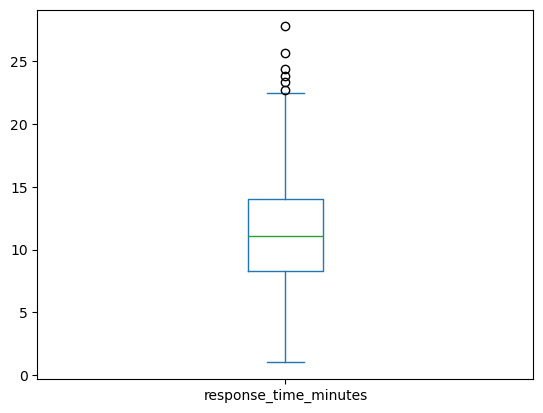

In [25]:
# Graph the distribution of the numeric variable with NULL
df['response_time_minutes'].plot(kind='box')
plt.show()

In [26]:
# % distribuction of Y
df['y'].value_counts(normalize=True)

y
1    0.506
0    0.494
Name: proportion, dtype: float64

In [27]:
# Count the number of categories on categorical variables
df.select_dtypes('object').nunique()

inputstate       50
gender            2
sexuality         6
trans             3
educ              6
votereg           3
race              8
employ            9
internethome      2
internetwork      2
marstat           6
pid3              5
ideo5             6
pew_bornagain     2
pew_religimp      4
pew_churatd       7
pew_prayer        8
religpew         12
newsint           5
faminc_new       17
ownhome           3
urbancity         5
immstat           5
cit1              2
unionhh           3
investor          2
dtype: int64

### Data cleaning and conversion

In [28]:
# Numeric columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numeric_cols.remove('y')
numeric_cols


['birthyr',
 'child18num',
 'assets_estimate',
 'response_time_minutes',
 'volunteering_index']

In [29]:
# Categorical columns
categorical_cols = df.select_dtypes(include='object').columns.tolist()
categorical_cols

['inputstate',
 'gender',
 'sexuality',
 'trans',
 'educ',
 'votereg',
 'race',
 'employ',
 'internethome',
 'internetwork',
 'marstat',
 'pid3',
 'ideo5',
 'pew_bornagain',
 'pew_religimp',
 'pew_churatd',
 'pew_prayer',
 'religpew',
 'newsint',
 'faminc_new',
 'ownhome',
 'urbancity',
 'immstat',
 'cit1',
 'unionhh',
 'investor']

In [30]:
# Imputation

numeric_pipe = Pipeline(steps=[
('imputer', SimpleImputer(strategy='median'))    
])

categorical_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy = 'constant', fill_value = 'missing')),
    ('onehot', OneHotEncoder(handle_unknown = 'ignore'))
])



In [ ]:
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipe, numeric_cols),
    ('cat', categorical_pipe, categorical_cols)
])



In [63]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# 1. Divide X and y
X = df.drop(columns='y')
y = df['y']

# 2. Redefinir columnas sobre X (sin 'y')
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(include='object').columns.tolist()

# 3. Pipelines
numeric_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# 4. Preprocessor
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipe, numeric_cols),
    ('cat', categorical_pipe, categorical_cols)
])

# 5. Train/val split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=20)

# 6. Full pipeline
full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

full_pipeline.fit(X_train, y_train)
print("Accuracy en validación:", full_pipeline.score(X_val, y_val))




Accuracy en validación: 0.71


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [64]:
print(y.value_counts(normalize=True))

y
1    0.506
0    0.494
Name: proportion, dtype: float64


In [ ]:
# ============================================
# IMPORTS
# ============================================
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

# ============================================
# 1. DATA PREPARATION
# ============================================
X = df.drop(columns='y')
y = df['y']

# ============================================
# 2. IDENTIFY COLUMN TYPES
# ============================================
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(include='object').columns.tolist()

# ============================================
# 3. TWO DIFFERENT NUMERIC PIPELINES
# ============================================

# Pipeline WITH scaling (for SVM, KNN, Logistic Regression)
numeric_pipe_with_scaler = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline WITHOUT scaling (for tree-based models and Naive Bayes)
numeric_pipe_without_scaler = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

# ============================================
# 4. CATEGORICAL PIPELINE (same for all models)
# ============================================
categorical_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
])

# ============================================
# 5. TWO DIFFERENT PREPROCESSORS
# ============================================

# Preprocessor WITH scaling
preprocessor_with_scaler = ColumnTransformer(transformers=[
    ('num', numeric_pipe_with_scaler, numeric_cols),
    ('cat', categorical_pipe, categorical_cols)
], sparse_threshold=0)

# Preprocessor WITHOUT scaling
preprocessor_without_scaler = ColumnTransformer(transformers=[
    ('num', numeric_pipe_without_scaler, numeric_cols),
    ('cat', categorical_pipe, categorical_cols)
], sparse_threshold=0)

# ============================================
# 6. TRAIN/VALIDATION SPLIT
# ============================================
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=20)

# ============================================
# 7. MODELS WITH THEIR CORRECT PREPROCESSOR
# ============================================

# Models that NEED scaling
models_that_need_scaling = {
    'SVM': SVC(random_state=20),
    'KNN': KNeighborsClassifier(),
    'Logistic Regression': LogisticRegression(max_iter=2000, solver='liblinear')
}

# Models that do NOT need scaling
models_that_dont_need_scaling = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=20),
    'Gradient Boosting': GradientBoostingClassifier(random_state=20),
    'XGBoost': XGBClassifier(random_state=20, eval_metric='logloss'),
    'Decision Tree': DecisionTreeClassifier(random_state=20),
    'Naive Bayes': GaussianNB(),
    'LDA': LinearDiscriminantAnalysis(),
    'QDA': QuadraticDiscriminantAnalysis(reg_param=0.1)
}

# ============================================
# 8. TRAIN ALL MODELS AND STORE RESULTS
# ============================================
results = []

# Train models that NEED scaling
for nombre, modelo in models_that_need_scaling.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor_with_scaler),
        ('classifier', modelo)
    ])
    pipeline.fit(X_train, y_train)
    acc = pipeline.score(X_val, y_val)
    results.append({'Model': nombre, 'Accuracy': acc, 'Scaled': 'YES'})

# Train models that do NOT need scaling
for nombre, modelo in models_that_dont_need_scaling.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor_without_scaler),
        ('classifier', modelo)
    ])
    pipeline.fit(X_train, y_train)
    acc = pipeline.score(X_val, y_val)
    results.append({'Model': nombre, 'Accuracy': acc, 'Scaled': 'NO'})

# ============================================
# 9. CREATE DATAFRAME AND SORT (BEST TO WORST)
# ============================================
df_results = pd.DataFrame(results)
df_sorted = df_results.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)

# ============================================
# 10. DISPLAY SORTED RESULTS
# ============================================
print("\n" + "="*60)
print("MODELS SORTED BY ACCURACY (Best to Worst)")
print("="*60)
print(df_sorted.to_string(index=True))
print("="*60)

# ============================================
# 11. DISPLAY BEST MODEL
# ============================================
best = df_sorted.iloc[0]
print(f"BEST MODEL: {best['Model']}")
print(f"   Accuracy: {best['Accuracy']:.4f} ({best['Accuracy']*100:.2f}%)")
print(f"   Scaled: {best['Scaled']}")
print("="*60)



MODELS SORTED BY ACCURACY (Best to Worst)
                 Model  Accuracy Scaled
0                  SVM  0.763333    YES
1                  QDA  0.750000     NO
2          Naive Bayes  0.730000     NO
3        Random Forest  0.723333     NO
4  Logistic Regression  0.720000    YES
5    Gradient Boosting  0.716667     NO
6                  LDA  0.703333     NO
7              XGBoost  0.680000     NO
8                  KNN  0.673333    YES
9        Decision Tree  0.610000     NO
BEST MODEL: SVM
   Accuracy: 0.7633 (76.33%)
   Scaled: YES


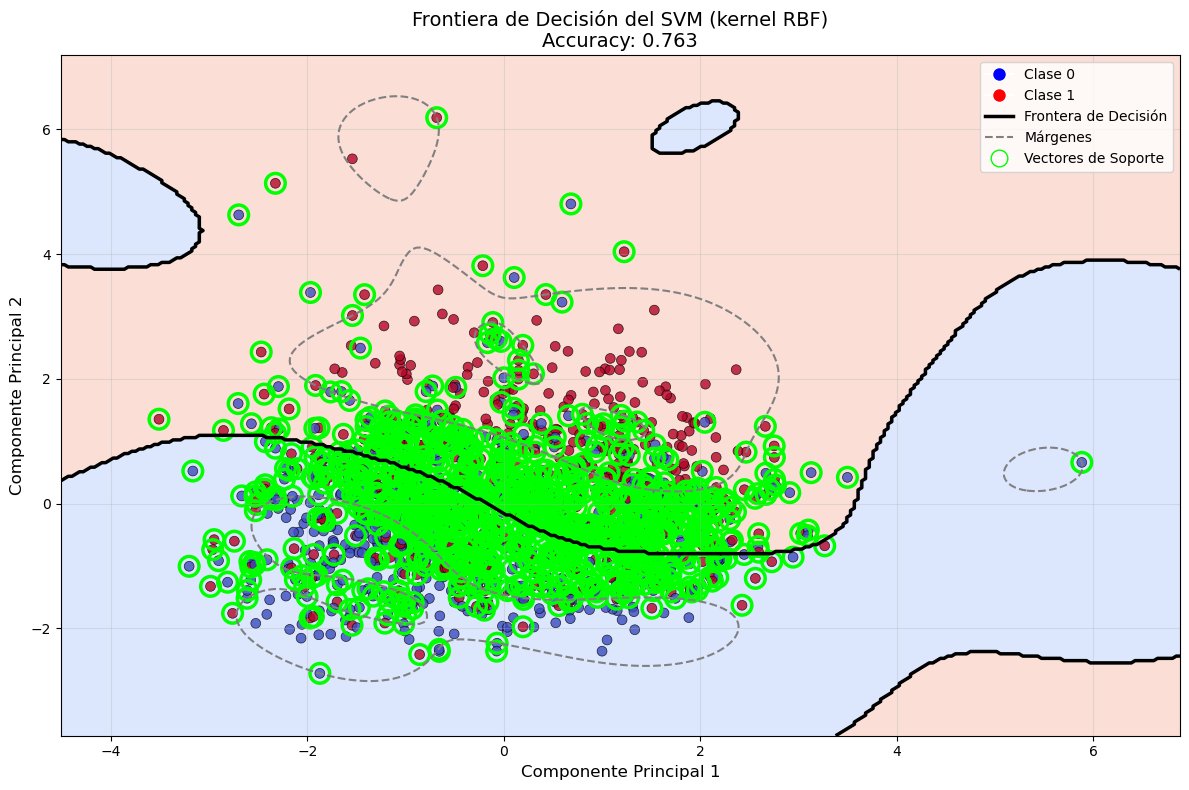


INFORMACIÓN DEL SVM
Número de Vectores de Soporte: 885
Varianza explicada por PC1: 11.09%
Varianza explicada por PC2: 8.18%
Varianza total en 2D: 19.27%


In [89]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import numpy as np

# ============================================
# 1. PREPARAR DATOS PARA VISUALIZACIÓN
# ============================================
# Usar solo 2 características para poder dibujar la línea
# Elige las 2 columnas numéricas más importantes de tus datos
# (cambia estos nombres por los de tus columnas reales)

# Opción A: Si quieres usar TODAS las variables pero reducidas a 2D con PCA
preprocessor_viz = ColumnTransformer(transformers=[
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), numeric_cols),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
        ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
    ]), categorical_cols)
], sparse_threshold=0)

# Transformar datos a espacio preprocesado
X_preprocessed = preprocessor_viz.fit_transform(X_train)

# Reducir a 2D con PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_preprocessed)

# ============================================
# 2. ENTRENAR SVM EN ESPACIO 2D
# ============================================
# Creamos SVM solo para visualización (en 2D)
svm_viz = SVC(kernel='rbf', C=1.0, random_state=20)
svm_viz.fit(X_pca, y_train)

# ============================================
# 3. CREAR MALLA PARA DIBUJAR LA LÍNEA
# ============================================
# Definir límites del gráfico
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1

# Crear una cuadrícula de puntos
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))

# Predecir la clase para cada punto de la cuadrícula
Z = svm_viz.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# ============================================
# 4. DIBUJAR LA FRONTERA DE DECISIÓN (LA LÍNEA)
# ============================================
fig, ax = plt.subplots(figsize=(12, 8))

# Dibujar las regiones de decisión (fondo)
contour = ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm', levels=[-0.5, 0.5, 1.5])

# DIBUJAR LA LÍNEA DE FRONTERA (el contorno en nivel 0)
contour_lines = ax.contour(xx, yy, Z, levels=[0], colors='black', linewidths=2.5, linestyles='-')

# Dibujar el margen del SVM (opcional: niveles -1 y 1)
try:
    # Calcular distancia al hiperplano
    Z_decision = svm_viz.decision_function(np.c_[xx.ravel(), yy.ravel()])
    Z_decision = Z_decision.reshape(xx.shape)
    # Dibujar márgenes como líneas punteadas
    ax.contour(xx, yy, Z_decision, levels=[-1, 1], colors='gray', linewidths=1.5, linestyles='--')
except:
    pass

# Dibujar los puntos de datos
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], 
                     c=y_train, cmap='coolwarm', 
                     s=50, alpha=0.8, edgecolors='k', linewidth=0.5)

# Destacar los Vectores de Soporte
support_vectors = svm_viz.support_vectors_
ax.scatter(support_vectors[:, 0], support_vectors[:, 1], 
           s=200, facecolors='none', edgecolors='lime', linewidth=2.5,
           label='Vectores de Soporte', marker='o')

# ============================================
# 5. FORMATO DEL GRÁFICO
# ============================================
ax.set_title(f'Frontiera de Decisión del SVM (kernel RBF)\n'
             f'Accuracy: {svm_pipeline.score(X_val, y_val):.3f}', 
             fontsize=14)
ax.set_xlabel('Componente Principal 1', fontsize=12)
ax.set_ylabel('Componente Principal 2', fontsize=12)

# Añadir leyenda personalizada
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', label='Clase 0',
                          markerfacecolor='blue', markersize=10),
                   Line2D([0], [0], marker='o', color='w', label='Clase 1',
                          markerfacecolor='red', markersize=10),
                   Line2D([0], [0], color='black', linewidth=2.5, label='Frontera de Decisión'),
                   Line2D([0], [0], color='gray', linewidth=1.5, linestyle='--', label='Márgenes'),
                   Line2D([0], [0], marker='o', color='w', label='Vectores de Soporte',
                          markerfacecolor='none', markeredgecolor='lime', markersize=12)]
ax.legend(handles=legend_elements, loc='best')

ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================
# 6. INFORMACIÓN ADICIONAL
# ============================================
print(f"\n{'='*50}")
print("INFORMACIÓN DEL SVM")
print('='*50)
print(f"Número de Vectores de Soporte: {len(svm_viz.support_vectors_)}")
print(f"Varianza explicada por PC1: {pca.explained_variance_ratio_[0]:.2%}")
print(f"Varianza explicada por PC2: {pca.explained_variance_ratio_[1]:.2%}")
print(f"Varianza total en 2D: {pca.explained_variance_ratio_.sum():.2%}")
print('='*50)